# Dynamic Window Approach
DWA samples dynamically reachable `(linear velocity, yaw rate)` pairs, rolls each constant command forward, scores heading/clearance/speed, executes the winner, and replans. Humans are treated as circles frozen at their current positions during each rollout.

In [1]:
from pathlib import Path
import sys
here = Path.cwd().resolve()
ROOT = next(p for p in (here, *here.parents) if (p / 'experiments/crowd_navigation/navigation.py').exists())
EXP = ROOT / 'experiments/crowd_navigation'
sys.path.insert(0, str(EXP))
from navigation import dependency_report, plot_episode, run_navigation_suite, summarize
dependency_report('dwa')

method                 dwa
rvo2                  True
casadi                True
acados_template       True
ACADOS_SOURCE_DIR    False
checkpoint            True
dtype: object

## One inspectable episode
The robot is unicycle-constrained. Change `SCENARIO`, `HUMAN_COUNT`, or `CASE` and rerun this cell to probe a failure.

[dwa] hallway_bottleneck case=0 success=True collisions=0 time=3.75s


,test_case,robot_policy,human_policy,scenario,success,timeout,navigation_time_s,steps,collision_steps,wall_collision_steps,...,path_length_m,path_efficiency,cumulative_reward,mean_policy_time_ms,max_policy_time_ms,mean_abs_linear_accel_mps2,mean_abs_angular_rate_radps,mean_abs_angular_accel_radps2,method,human_count
0,0,DynamicWindowApproach,ORCAPlus,hallway_bottleneck,True,False,3.75,15,0,0,...,1.8,0.99999,1.0,14.650347,20.237666,0.242857,0.011455,0.077448,dwa,6


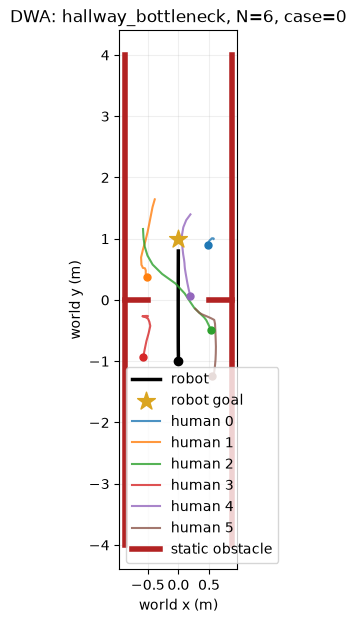

In [2]:
SCENARIO = 'hallway_bottleneck'
HUMAN_COUNT = 6
CASE = 0
one, episodes = run_navigation_suite('dwa', cases=[CASE], scenario=SCENARIO, human_count=HUMAN_COUNT, device='auto')
display(one)
plot_episode(episodes[CASE], title=f'DWA: {SCENARIO}, N={HUMAN_COUNT}, case={CASE}');

## Deterministic suite
Results are persisted in the common filename format consumed by the comparison notebook.

In [3]:
results, _ = run_navigation_suite('dwa', cases=range(25), scenario=SCENARIO, human_count=HUMAN_COUNT, device='auto', output_dir=EXP/'outputs/policy_benchmark')
summarize(results)

[dwa] hallway_bottleneck case=0 success=True collisions=0 time=3.75s
[dwa] hallway_bottleneck case=1 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=2 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=3 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=4 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=5 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=6 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=7 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=8 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=9 success=False collisions=0 time=30.25s
[dwa] hallway_bottleneck case=10 success=True collisions=0 time=15.50s
[dwa] hallway_bottleneck case=11 success=True collisions=0 time=11.50s
[dwa] hallway_bottleneck case=12 success=True collisions=0 time=18.00s
[dwa] hallway_bottleneck case=13 success=False collisions=0 time=30.25s
[dwa] h

episodes                             25.000000
success_rate                          0.360000
timeout_rate                          0.640000
episodes_with_collision_rate          0.000000
episodes_with_wall_collision_rate     0.000000
mean_navigation_time_s               25.050000
mean_minimum_clearance_m              0.100610
mean_path_efficiency                  0.682455
mean_policy_time_ms                  17.488542
mean_abs_linear_accel_mps2            0.141469
mean_abs_angular_rate_radps           0.023320
mean_abs_angular_accel_radps2         0.097415
dtype: float64